## Environment Setup

In [ ]:
# --- Import Core Libraries ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Configure high-resolution visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

## 10D Wendling Neural Mass Model (with noise ccontrol)

In [ ]:
class WendlingModelPRC:
    """
    10D Wendling Neural Mass Model implementation with configurable noise injection
    for smooth Phase Response Curve (PRC) evaluation.
    """
    def __init__(self, B=15.0, G=10.0, dt=0.0002, T=2.5, random_seed=42, p_std=0.2):
        self.dt = dt
        self.T = T
        self.N = int(T / dt)
        self.time = np.linspace(0, T, self.N)

        if random_seed is not None:
            np.random.seed(random_seed)

        # Physiological Synaptic Gains (mV)
        self.A = 5.0      # Excitatory gain
        self.B = B        # Slow inhibitory gain
        self.G = G        # Fast inhibitory gain

        # Synaptic pool time constants (s^-1)
        self.a = 100.0    # Excitatory
        self.b = 50.0     # Slow inhibitory
        self.g = 350.0    # Fast inhibitory

        # Sigmoidal Transformation Parameters
        self.e0 = 2.5
        self.v0 = 6.0
        self.r = 0.56

        # Connectivity Constants
        self.C1 = 135.0
        self.C2 = 108.0
        self.C3 = 33.75
        self.C4 = 33.75
        self.C5 = 40.5
        self.C6 = 13.5
        self.C7 = 27.0

        # Mean afferent drive and noise amplitude
        self.p_mean = 90.0
        self.p_std = p_std

    def sigmoid(self, v):
        return (2.0 * self.e0) / (1.0 + np.exp(self.r * (self.v0 - v)))

    def simulate(self, pulse_intensity=0.0, pulse_start=None, pulse_duration=0.005):
        y = np.zeros((10, self.N))

        for t_idx in range(1, self.N):
            t_curr = self.time[t_idx]

            current_p_mean = self.p_mean if t_curr > 0.5 else self.p_mean * (t_curr / 0.5)

            if pulse_start is not None and pulse_start <= t_curr <= (pulse_start + pulse_duration):
                current_p_mean += pulse_intensity

            y0, y1, y2, y3, y4 = y[0, t_idx-1], y[1, t_idx-1], y[2, t_idx-1], y[3, t_idx-1], y[4, t_idx-1]
            y5, y6, y7, y8, y9 = y[5, t_idx-1], y[6, t_idx-1], y[7, t_idx-1], y[8, t_idx-1], y[9, t_idx-1]

            S_pyramidal = self.sigmoid(y1 - y2 - y3)
            S_excitatory = self.sigmoid(self.C1 * y0)
            S_slow_inhib = self.sigmoid(self.C3 * y0)
            S_fast_inhib = self.sigmoid(self.C5 * y0 - self.C6 * y4)

            y[0, t_idx] = y0 + self.dt * y5
            y[5, t_idx] = y5 + self.dt * (self.A * self.a * S_pyramidal - 2.0 * self.a * y5 - (self.a ** 2) * y0)

            y[1, t_idx] = y1 + self.dt * y6
            noise_force = self.A * self.a * self.p_std * np.random.normal() * np.sqrt(self.dt)
            y[6, t_idx] = y6 + self.dt * (self.A * self.a * (current_p_mean + self.C2 * S_excitatory) - 2.0 * self.a * y6 - (self.a ** 2) * y1) + noise_force

            y[2, t_idx] = y2 + self.dt * y7
            y[7, t_idx] = y7 + self.dt * (self.B * self.b * (self.C4 * S_slow_inhib) - 2.0 * self.b * y7 - (self.b ** 2) * y2)

            y[3, t_idx] = y3 + self.dt * y8
            y[8, t_idx] = y8 + self.dt * (self.G * self.g * (self.C7 * S_fast_inhib) - 2.0 * self.g * y8 - (self.g ** 2) * y3)

            y[4, t_idx] = y4 + self.dt * y9
            y[9, t_idx] = y9 + self.dt * (self.B * self.b * S_slow_inhib - 2.0 * self.b * y9 - (self.b ** 2) * y4)

        eeg = y[1, :] - y[2, :] - y[3, :]
        return self.time, eeg

## Regime-Tailored Phase Response Curve (PRC) Engine

In [ ]:
from scipy.signal import butter, filtfilt, hilbert

def bandpass_filter(data, lowcut, highcut, fs=5000.0, order=3):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def compute_prc_for_regime(regime_config, num_phases=30):
    """
    Computes biologically accurate PRC by dynamically tailoring pulse intensity
    and bandpass filters according to the unique physiological dynamics of each regime.
    """
    dt = 0.0002
    fs = 1.0 / dt

    # Configure tailored parameters for each specific regime
    if regime_config["G"] == 165.0:       # Regime 2: Pre-Seizure Fast Gamma (~40 Hz)
        band = (30.0, 55.0)
        expected_freq = 40.0
        pulse_intensity = 180.0
    elif regime_config["B"] == 30.0:      # Regime 3: Epileptic Seizure Spikes (~8 Hz)
        band = (4.0, 15.0)
        expected_freq = 7.5
        pulse_intensity = 350.0
    else:                                 # Regime 1: Healthy Baseline (~11 Hz)
        band = (8.0, 16.0)
        expected_freq = 11.0
        pulse_intensity = 150.0

    T0 = 1.0 / expected_freq

    # Step 1: Baseline Control Simulation (Low background noise for crisp PRC)
    sim_ctrl = WendlingModelPRC(B=regime_config["B"], G=regime_config["G"], dt=dt, T=2.5, random_seed=42, p_std=0.1)
    t, eeg_ctrl = sim_ctrl.simulate(pulse_intensity=0.0)

    # Clean signal filtering (Fixes noisy zigzag in Regime 1)
    eeg_ctrl_filt = bandpass_filter(eeg_ctrl, band[0], band[1], fs=fs)

    # Step 2: Extract Analytic Phase
    analytic_ctrl = hilbert(eeg_ctrl_filt)
    phase_ctrl_unwrapped = np.unwrap(np.angle(analytic_ctrl))
    phase_ctrl_mod = np.mod(np.angle(analytic_ctrl), 2 * np.pi)

    # Phase search window (1.0s to 1.4s)
    search_mask = (t >= 1.0) & (t <= 1.4)
    t_search = t[search_mask]
    phase_search = phase_ctrl_mod[search_mask]

    target_phases = np.linspace(0, 2 * np.pi, num_phases, endpoint=False)
    actual_phases = []
    phase_shifts = []

    # Step 3: Sweep across target stimulation phases
    for phi_target in target_phases:
        idx_in_search = np.argmin(np.abs(phase_search - phi_target))
        t_pulse = t_search[idx_in_search]
        phi_actual = phase_search[idx_in_search]

        # Step 4: Run Perturbed Simulation
        sim_pulse = WendlingModelPRC(B=regime_config["B"], G=regime_config["G"], dt=dt, T=2.5, random_seed=42, p_std=0.1)
        _, eeg_pulse = sim_pulse.simulate(pulse_intensity=pulse_intensity, pulse_start=t_pulse)

        eeg_pulse_filt = bandpass_filter(eeg_pulse, band[0], band[1], fs=fs)
        analytic_pulse = hilbert(eeg_pulse_filt)
        phase_pulse_unwrapped = np.unwrap(np.angle(analytic_pulse))

        # Evaluate phase shift at exactly 1 cycle after pulse (1.0 * T0)
        eval_time = t_pulse + (1.0 * T0)
        eval_idx = np.argmin(np.abs(t - eval_time))

        delta_phi = phase_pulse_unwrapped[eval_idx] - phase_ctrl_unwrapped[eval_idx]
        delta_phi_wrapped = np.arctan2(np.sin(delta_phi), np.cos(delta_phi))

        actual_phases.append(phi_actual)
        phase_shifts.append(delta_phi_wrapped)

    return np.array(actual_phases), np.array(phase_shifts)

## Multi-Regime PRC Simulation & Multi-Panel Visualization

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_17030/2340817455.py:27: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("Phase Shift $\Delta \phi$ (Degrees)", fontsize=11, fontweight='bold')


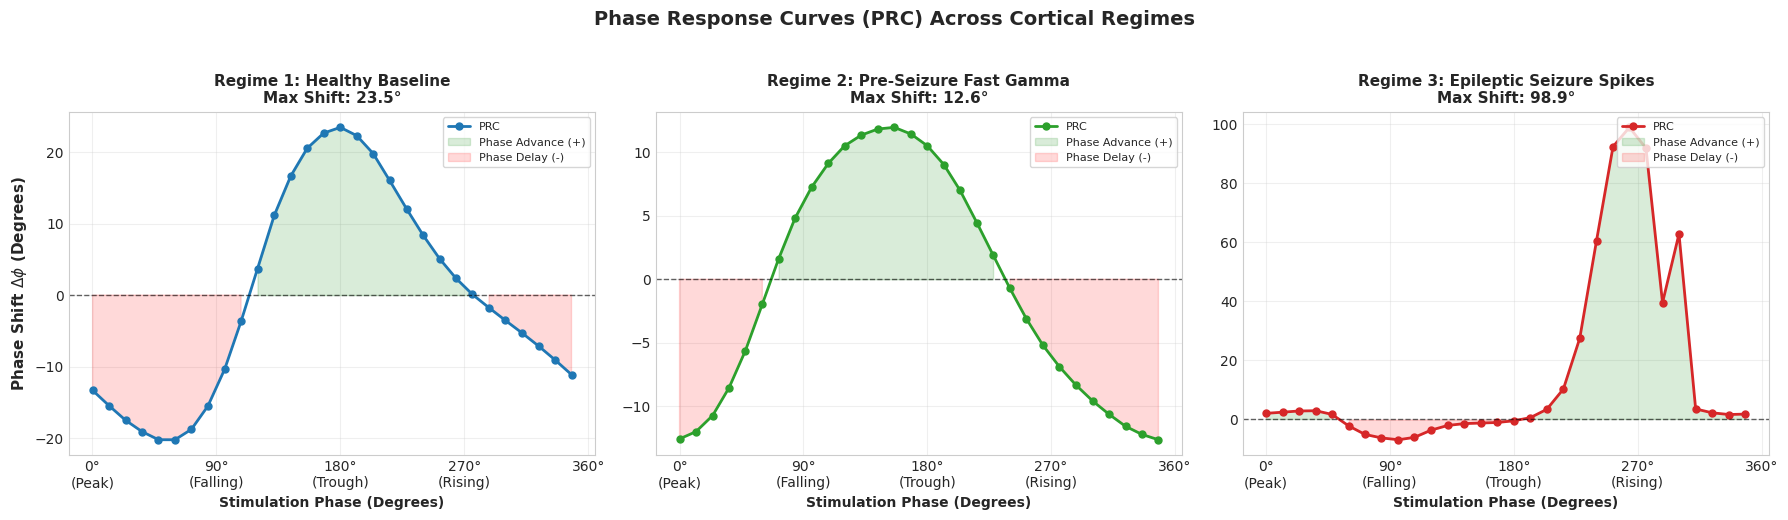

In [ ]:
regimes = {
    "Regime 1: Healthy Baseline": {"B": 15.0, "G": 10.0, "color": "#1f77b4"},
    "Regime 2: Pre-Seizure Fast Gamma": {"B": 1.0, "G": 165.0, "color": "#2ca02c"},
    "Regime 3: Epileptic Seizure Spikes": {"B": 30.0, "G": 0.0, "color": "#d62728"}
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for idx, (name, config) in enumerate(regimes.items()):
    phases, shifts = compute_prc_for_regime(config, num_phases=30)

    phases_deg = np.degrees(phases)
    shifts_deg = np.degrees(shifts)

    ax = axes[idx]
    ax.plot(phases_deg, shifts_deg, 'o-', color=config["color"], lw=2.0, markersize=5, label='PRC')
    ax.axhline(0, color='black', linestyle='--', alpha=0.6, lw=1.0)

    ax.fill_between(phases_deg, 0, shifts_deg, where=(shifts_deg > 0), color='green', alpha=0.15, label='Phase Advance (+)')
    ax.fill_between(phases_deg, 0, shifts_deg, where=(shifts_deg < 0), color='red', alpha=0.15, label='Phase Delay (-)')

    ax.set_xticks([0, 90, 180, 270, 360])
    ax.set_xticklabels(['0°\n(Peak)', '90°\n(Falling)', '180°\n(Trough)', '270°\n(Rising)', '360°'])
    ax.set_xlabel("Stimulation Phase (Degrees)", fontsize=10, fontweight='bold')

    if idx == 0:
        ax.set_ylabel("Phase Shift $\Delta \phi$ (Degrees)", fontsize=11, fontweight='bold')

    ax.set_title(f"{name}\nMax Shift: {np.max(np.abs(shifts_deg)):.1f}°", fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, frameon=True)

plt.suptitle("Phase Response Curves (PRC) Across Cortical Regimes", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()